Binary classification problem with Support Vector Machine (SVM)

In [ ]:
from sklearn import svm     # Module for SVM
import numpy as np
import matplotlib.pyplot as plt

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


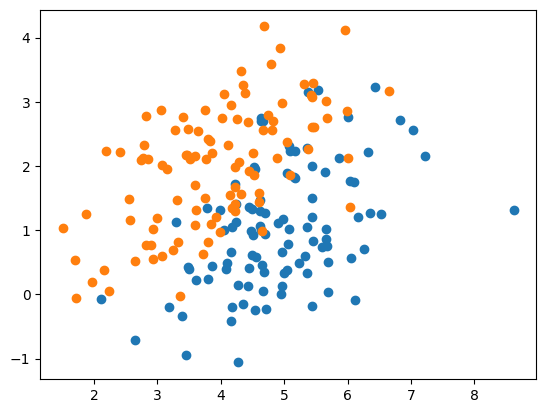

In [ ]:
# Make Data with the multivariate normal distributions
N1 = 100
N2 = 100
c1 = np.random.multivariate_normal([5,1], [[1,0.5],[0.5,1]], N1)
c2 = np.random.multivariate_normal([4,2], [[1,0.5],[0.5,1]], N2)

# Combine the samples into one dataset
smpls = np.vstack([c1, c2])

# Target variable
y = np.hstack([np.repeat(1, N1), np.repeat(0, N2)])
print(y)

# Plot the data
plt.scatter(c1[:,0], c1[:,1])
plt.scatter(c2[:,0], c2[:,1])

Develop a SVM classifier for the data

RBF kernel (sklearn.svm)

The Radial Basis Function (RBF) kernel is defined as:
$$
k(\mathbf{x}_i,\mathbf{x}_j) = \exp(-\gamma\|\mathbf{x}_i - \mathbf{x}_j\|_2^2)
$$

SVM

The SVM objective function is given by:
$$
\min \frac{1}{2}\|\mathbf{w}\|_2 + C\sum_i \xi_i \\
\text{subject to}\;y_i(\mathbf{w}^T\mathbf{x}_i+b) \ge 1 - \xi_i
$$

In [ ]:
sigma = 1.0   # Lengthscale of the RBF kernel, equivalent to 1/gamma
C = 0.05    # Regularization parameter for the SVM
model = svm.SVC(kernel='rbf', gamma=1/sigma, C=C).fit(smpls, y)     # Train the SVM classifier

# Uncomment the following lines if you want to view the support vectors
# and the predictions for the training data
# print(model.support_vectors_)
# print(model.predict(smpls))

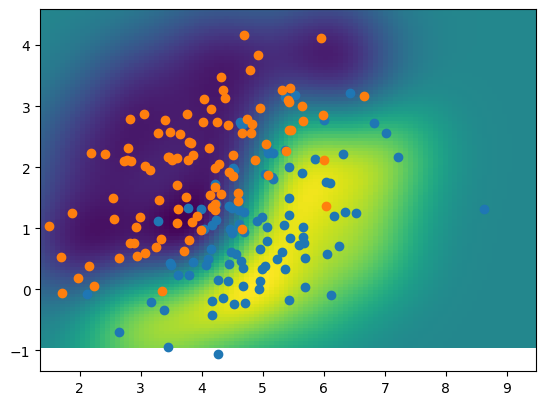

In [ ]:
# Define a grid over the feature space for making predictions
x1min = np.min(smpls[:,0]) * 0.9
x1max = np.max(smpls[:,0]) * 1.1
x2min = np.min(smpls[:,1]) * 0.9
x2max = np.max(smpls[:,1]) * 1.1
x1,x2 = np.meshgrid(np.linspace(x1min, x1max, 100), np.linspace(x2min, x2max, 100))

# Combine the grid points into a set of 2D coordinates
pos = np.vstack([x1.ravel(), x2.ravel()]).T

# Make predictions across the grid using the trained SVM model
f = model.decision_function(pos).reshape(x1.shape)

# Plot the decision function
plt.imshow(f, extent=[x1min, x1max, x2min, x2max], origin='lower')
plt.scatter(c1[:,0],c1[:,1])
plt.scatter(c2[:,0],c2[:,1])

Exercise
1. Adjust the kernel parameter `sigma` (the lengthscale of the RBF kernel) and observe how it affects the decision boundary.
2. Modify the penalty coefficient `C` and examine its impact on the SVM model's performance and the decision boundary.

Calculate the cross-validated ROC-AUC of the classifier

In [ ]:
from sklearn.model_selection import cross_val_score     # Function for performing cross-validation

In [ ]:
sigma = 1.0    # Lengthscale of RBF kernel, corresponding to 1/gamma
C = 0.05     # Regularization parameter
metric = 'roc_auc'     # Metric for evaluating model performance
model = svm.SVC(kernel='rbf', gamma=1/sigma, C=C)
scores = cross_val_score(model, smpls, y, cv=10, scoring=metric)     # 10-fold cross-validation
print(scores, scores.mean(), scores.std())     # Print individual scores, mean, and standard deviation

[0.86 0.91 0.76 0.84 0.92 0.95 0.93 0.97 1.   0.88] 0.9020000000000001 0.06630233781700309


Text(0.5, 1.0, 'Cross-validated ROC-AUC vs. Penalty Coefficient (C)')

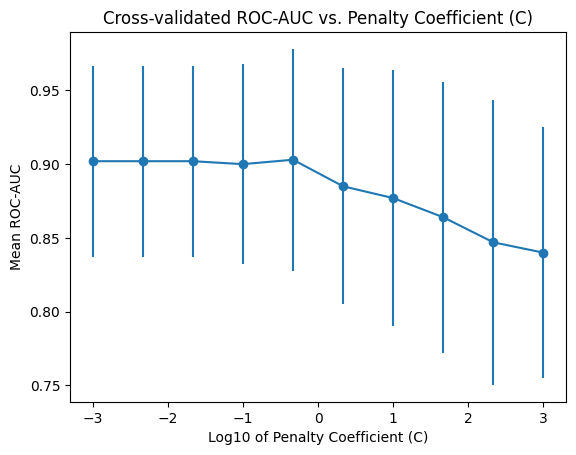

In [ ]:
Nc = 10
Cs = 10**np.linspace(-3, 3, Nc)  # Range of penalty coefficients
metric = 'roc_auc'
# metric = 'accuracy'

# Compute cross-validated ROC-AUC scores and their standard deviations
scores = [cross_val_score(svm.SVC(kernel='rbf', gamma=1/sigma, C=C), smpls, y, cv=10, scoring=metric) for C in Cs]
cve = [score.mean() for score in scores]
cvstd = [score.std() for score in scores]

# Plot the results
plt.errorbar(np.log10(Cs), cve, yerr=cvstd, fmt='-o')
plt.xlabel('Log10 of Penalty Coefficient (C)')
plt.ylabel('Mean ROC-AUC')
plt.title('Cross-validated ROC-AUC vs. Penalty Coefficient (C)')

Exercise
3. In the `cross_val_score()` function, you can use different metrics such as 'accuracy', 'precision', 'recall', 'f1', and others in addition to 'roc_auc'. Experiment with some of these metrics and compare the results.
4. Consider a situation with highly imbalanced sample sizes (e.g., significantly different values for N1 and N2). Compare the performance metrics (ROC-AUC and accuracy) in this scenario.

0.46415888336127775


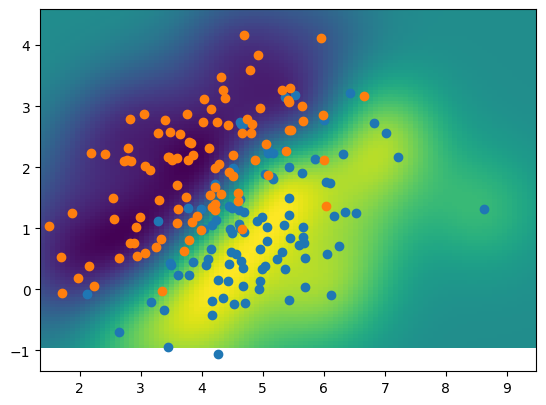

In [ ]:
# Find the best model based on cross-validation scores
C_best = Cs[np.argmax(cve)]
print(C_best)

# Train the SVM model with the best C
model = svm.SVC(kernel='rbf', gamma=1/sigma, C=C_best).fit(smpls, y)

# Prediction
f = model.decision_function(pos).reshape(x1.shape)

# Plot the decision function
plt.imshow(f, extent=[x1min, x1max, x2min, x2max], origin='lower')
plt.scatter(c1[:,0], c1[:,1])
plt.scatter(c2[:,0], c2[:,1])